# All 6 Peptides: Geodesic Distance Analysis

Compute local Riemannian distances from each starting peptide to all MUTANG-generated peptides, then analyze mean distance as a function of top-k% by softmax potential.

In [2]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pep_compass.models.encoder_decoder.hydramp_encoder_decoder import HydrAMPEncoderDecoder
from pep_compass.models.encoder_decoder.utils import decoder_jacobian
from pep_compass.local_enumeration.mutation.utils import get_mutations_from_s_u_standard
from pep_compass.local_enumeration.sampling.sorbes import SubRiemannianTangentSpace
from pep_compass.local_enumeration.mutation.mutation_potentials import ProjectedDirectionPairwiseSimilarityPotential
from pep_compass.geometry.utils import metric_from_jac


device = torch.device("cpu")
hydramp = HydrAMPEncoderDecoder(
    jacobian_mode="approx",
    jacobian_eps=1e-6,
    field_eps=1e-6,
    device=device,
)

alphabet = list(" ACDEFGHIKLMNPQRSTVWY")
run_peptides = {
    "middle-1": "FLYKWWIRIGRLKL",
    "jurand-2": "KFRNRHRWKFKLIFRN",
    "jurand-4": "KYCRRFRWLTFRWL",
    "jurand-7": "KKYWLIRKWIRLWFLT",
    "mammuthusin-3": "KTLKIIRLLF",
    "hydrodamin-2": "RMARNLVRYVQGLKKKKVI",
}
run_names = list(run_peptides.keys())

# Use explicit workspace path to avoid notebook working-directory ambiguity.
results_dir = Path(r"c:\Users\Karol\Desktop\PepCompass\pep-compass\results")
if not results_dir.exists():
    raise FileNotFoundError(f"Results directory not found: {results_dir}")

# Use the MuTang / MuTang++ start peptides directly.
# Detailed resolution for top-k curves: every 0.1%
k_grid = np.arange(0.1, 100.0001, 0.1)
batch_size = 2048

print(f"Using results dir: {results_dir}")
print("Loaded run peptides:")
for n in run_names:
    print(f"  {n}: {run_peptides[n]}")

Using results dir: c:\Users\Karol\Desktop\PepCompass\pep-compass\results
Loaded run peptides:
  middle-1: FLYKWWIRIGRLKL
  jurand-2: KFRNRHRWKFKLIFRN
  jurand-4: KYCRRFRWLTFRWL
  jurand-7: KKYWLIRKWIRLWFLT
  mammuthusin-3: KTLKIIRLLF
  hydrodamin-2: RMARNLVRYVQGLKKKKVI


In [4]:
direction_significance_thresholds = [1e-6, 6e-5, 1.51e-6, 1e-4, 1e-6, 5e-4]
token_thresholds = [1e-4, 1e-4, 1e-4, 5e-4, 1e-4, 1e-3]

In [7]:
def return_potentials_softmax(potentials: dict[tuple[int, ...], float]) -> dict[tuple[int, ...], float]:
    if not potentials:
        return {}
    keys = list(potentials.keys())
    values = np.array([potentials[k] for k in keys], dtype=np.float64)
    shifted = values - np.max(values)
    exp_vals = np.exp(shifted)
    probs = exp_vals / np.sum(exp_vals)
    return {k: float(p) for k, p in zip(keys, probs)}

def aa_tuple_to_sequence(
    aa_tuple: tuple[int, ...],
    base_peptide: str,
    positions: list[int],
    alphabet: list[str],
) -> str:
    chars = list(base_peptide)
    for local_i, aa_idx in enumerate(aa_tuple):
        chars[positions[local_i]] = alphabet[aa_idx]
    return "".join(chars)

def local_riemannian_distances_from_start(
    start_peptide: str,
    sequences: list[str],
    hydramp_model: HydrAMPEncoderDecoder,
    bs: int = 2048,
) -> np.ndarray:
    z_start = hydramp_model.encode_peptides([start_peptide]).detach()

    jac_start = decoder_jacobian(
        lambda x: hydramp_model.decoder_forward(x, softmax=True, flatten=True),
        z_start,
        jacobian_fn_mode="approx",
        jacobian_fn_kwargs={"jacobian_eps": 1e-6},
    )
    g_start = metric_from_jac(jac_start)[0]

    chunks = []
    for i in range(0, len(sequences), bs):
        z_batch = hydramp_model.encode_peptides(sequences[i:i + bs]).detach()
        chunks.append(z_batch)
    all_latents = torch.cat(chunks, dim=0)

    delta = all_latents - z_start
    dist2 = torch.einsum("bi,ij,bj->b", delta, g_start, delta)
    return torch.sqrt(torch.clamp(dist2, min=0.0)).cpu().numpy()

In [8]:
curve_rows = []
summary_rows = []
sorted_distance_rows = []

if len(direction_significance_thresholds) != len(run_names):
    raise ValueError("direction_significance_thresholds length must match run_names length")
if len(token_thresholds) != len(run_names):
    raise ValueError("token_thresholds length must match run_names length")

for i, run_name in enumerate(run_names):
    peptide = run_peptides[run_name]
    pep_len = len(peptide)

    direction_thr = direction_significance_thresholds[i]
    token_thr = token_thresholds[i]

    z = hydramp.encode_peptides([peptide])
    jac = decoder_jacobian(
        lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
        z,
        jacobian_fn_mode="approx",
        jacobian_fn_kwargs={"jacobian_eps": 1e-6},
    )

    U, S, V = torch.linalg.svd(jac, full_matrices=False)

    mutations = get_mutations_from_s_u_standard(
        s=S[0].detach().cpu().numpy(),
        u=U[0].detach().cpu().numpy(),
        max_len=25,
        alphabet_size=21,
        direction_significance_threshold=direction_thr,
        min_number_of_directions=3,
        token_threshold=token_thr,
    )
    mutations = {pos: muts for pos, muts in mutations.items() if pos < pep_len}

    # Print product of mutation counts per position.
    total_combos = 1
    for pos, muts in mutations.items():
        unique_muts = set(muts)
        if len(unique_muts) != len(muts):
            muts = list(unique_muts)
        total_combos *= (len(muts) + 1)

    print(
        f"{run_name}: direction_thr={direction_thr:.2e}, token_thr={token_thr:.2e}, total_combos={total_combos}"
    )

    positions = sorted(mutations.keys())

    tangent_space = SubRiemannianTangentSpace(
        U=U[0],
        S=S[0],
        V=V[0],
        horizontal_threshold=1e-4,
        device="cpu",
    )
    potential = ProjectedDirectionPairwiseSimilarityPotential(tangent_space=tangent_space)

    potentials = potential.compute_with_identities(peptide, mutations)
    probs_dict = return_potentials_softmax(potentials)

    combos = list(probs_dict.keys())
    probs = np.array([probs_dict[c] for c in combos], dtype=np.float64)

    sequences = [aa_tuple_to_sequence(c, peptide, positions, alphabet) for c in combos]
    distances = local_riemannian_distances_from_start(peptide, sequences, hydramp, bs=batch_size)

    order = np.argsort(-probs)
    probs_sorted = probs[order]
    d_sorted = distances[order]
    combos_sorted = [combos[idx] for idx in order]

    N = len(d_sorted)
    thr_1N = 1.0 / N
    thr_halfN = 2.0 / N

    pct_1N = 100.0 * float(np.mean(probs >= thr_1N))
    pct_halfN = 100.0 * float(np.mean(probs >= thr_halfN))

    mean_all = float(np.mean(distances))
    mask_1N = probs >= thr_1N
    mean_above_1N = float(np.mean(distances[mask_1N])) if np.any(mask_1N) else np.nan

    csum = np.cumsum(d_sorted)

    # Save detailed sorted distances/probabilities for each peptide.
    for rank_idx in range(N):
        rank = rank_idx + 1
        sorted_distance_rows.append({
            "run_name": run_name,
            "start_peptide": peptide,
            "rank": rank,
            "rank_percent": 100.0 * rank / N,
            "combo": str(combos_sorted[rank_idx]),
            "softmax_probability": float(probs_sorted[rank_idx]),
            "distance": float(d_sorted[rank_idx]),
            "cumulative_mean_distance": float(csum[rank_idx] / rank),
        })

    for k in k_grid:
        n_top = max(1, int(math.ceil((k / 100.0) * N)))
        mean_top_k = float(csum[n_top - 1] / n_top)
        curve_rows.append({
            "run_name": run_name,
            "start_peptide": peptide,
            "k_percent": float(k),
            "mean_distance_top_k": mean_top_k,
        })

    summary_rows.append({
        "run_name": run_name,
        "start_peptide": peptide,
        "num_candidates": N,
        "mean_distance_all": mean_all,
        "mean_distance_above_1N": mean_above_1N,
        "threshold_1_over_N": thr_1N,
        "threshold_2_over_N": thr_halfN,
        "x_percent_for_1_over_N": pct_1N,
        "x_percent_for_2_over_N": pct_halfN,
        "direction_significance_threshold": direction_thr,
        "token_threshold": token_thr,
        "total_combos": total_combos,
    })

    print(
        f"Done: {run_name} | N={N} | mean_all={mean_all:.6f} | mean_above_1N={mean_above_1N:.6f}"
    )

curve_df = pd.DataFrame(curve_rows)
summary_df = pd.DataFrame(summary_rows).sort_values("run_name").reset_index(drop=True)
sorted_distances_df = pd.DataFrame(sorted_distance_rows)

# Save detailed and aggregate outputs.
dataframes_dir = results_dir / "dataframes"
dataframes_dir.mkdir(parents=True, exist_ok=True)
curve_out = dataframes_dir / "all_6_geodesic_curve_0p1pct.csv"
summary_out = dataframes_dir / "all_6_geodesic_summary.csv"
sorted_out = dataframes_dir / "all_6_geodesic_sorted_distances.csv"
curve_df.to_csv(curve_out, index=False)
summary_df.to_csv(summary_out, index=False)
sorted_distances_df.to_csv(sorted_out, index=False)

print(f"Saved: {curve_out}")
print(f"Saved: {summary_out}")
print(f"Saved: {sorted_out}")

summary_df

middle-1: direction_thr=1.00e-06, token_thr=1.00e-04, total_combos=48384
Done: middle-1 | N=48383 | mean_all=0.001314 | mean_above_1N=0.001185
jurand-2: direction_thr=6.00e-05, token_thr=1.00e-04, total_combos=138240
Done: jurand-2 | N=100799 | mean_all=3.581884 | mean_above_1N=3.545508
jurand-4: direction_thr=1.51e-06, token_thr=1.00e-04, total_combos=100800
Done: jurand-4 | N=80639 | mean_all=0.035680 | mean_above_1N=0.037318
jurand-7: direction_thr=1.00e-04, token_thr=5.00e-04, total_combos=120960
Done: jurand-7 | N=53759 | mean_all=0.392428 | mean_above_1N=0.397190
mammuthusin-3: direction_thr=1.00e-06, token_thr=1.00e-04, total_combos=80640
Done: mammuthusin-3 | N=80639 | mean_all=0.003815 | mean_above_1N=0.003604
hydrodamin-2: direction_thr=5.00e-04, token_thr=1.00e-03, total_combos=40500
Done: hydrodamin-2 | N=24299 | mean_all=0.123706 | mean_above_1N=0.110346
Saved: c:\Users\Karol\Desktop\PepCompass\pep-compass\results\dataframes\all_6_geodesic_curve_0p1pct.csv
Saved: c:\Users\

,run_name,start_peptide,num_candidates,mean_distance_all,mean_distance_above_1N,threshold_1_over_N,threshold_2_over_N,x_percent_for_1_over_N,x_percent_for_2_over_N,direction_significance_threshold,token_threshold,total_combos
0,hydrodamin-2,RMARNLVRYVQGLKKKKVI,24299,0.123706,0.110346,0.000041,0.000082,55.874727,0.000000,0.000500,0.0010,40500
1,jurand-2,KFRNRHRWKFKLIFRN,100799,3.581884,3.545508,0.000010,0.000020,47.989563,0.000000,0.000060,0.0001,138240
2,jurand-4,KYCRRFRWLTFRWL,80639,0.035680,0.037318,0.000012,0.000025,26.515706,15.342452,0.000002,0.0001,100800
3,jurand-7,KKYWLIRKWIRLWFLT,53759,0.392428,0.397190,0.000019,0.000037,54.859651,0.000000,0.000100,0.0005,120960
4,mammuthusin-3,KTLKIIRLLF,80639,0.003815,0.003604,0.000012,0.000025,38.032466,6.737435,0.000001,0.0001,80640
5,middle-1,FLYKWWIRIGRLKL,48383,0.001314,0.001185,0.000021,0.000041,45.530455,0.000000,0.000001,0.0001,48384


In [5]:
direction_significance_thresholds = [1e-6, 6e-5, 1.51e-6, 1e-4, 1e-6, 5e-4]
token_thresholds = [1e-4, 1e-4, 1e-4, 5e-4, 1e-4, 1e-3]

Saved plot: c:\Users\Karol\Desktop\PepCompass\pep-compass\results\plots\all_6_geodesic_topk_0p1pct.png


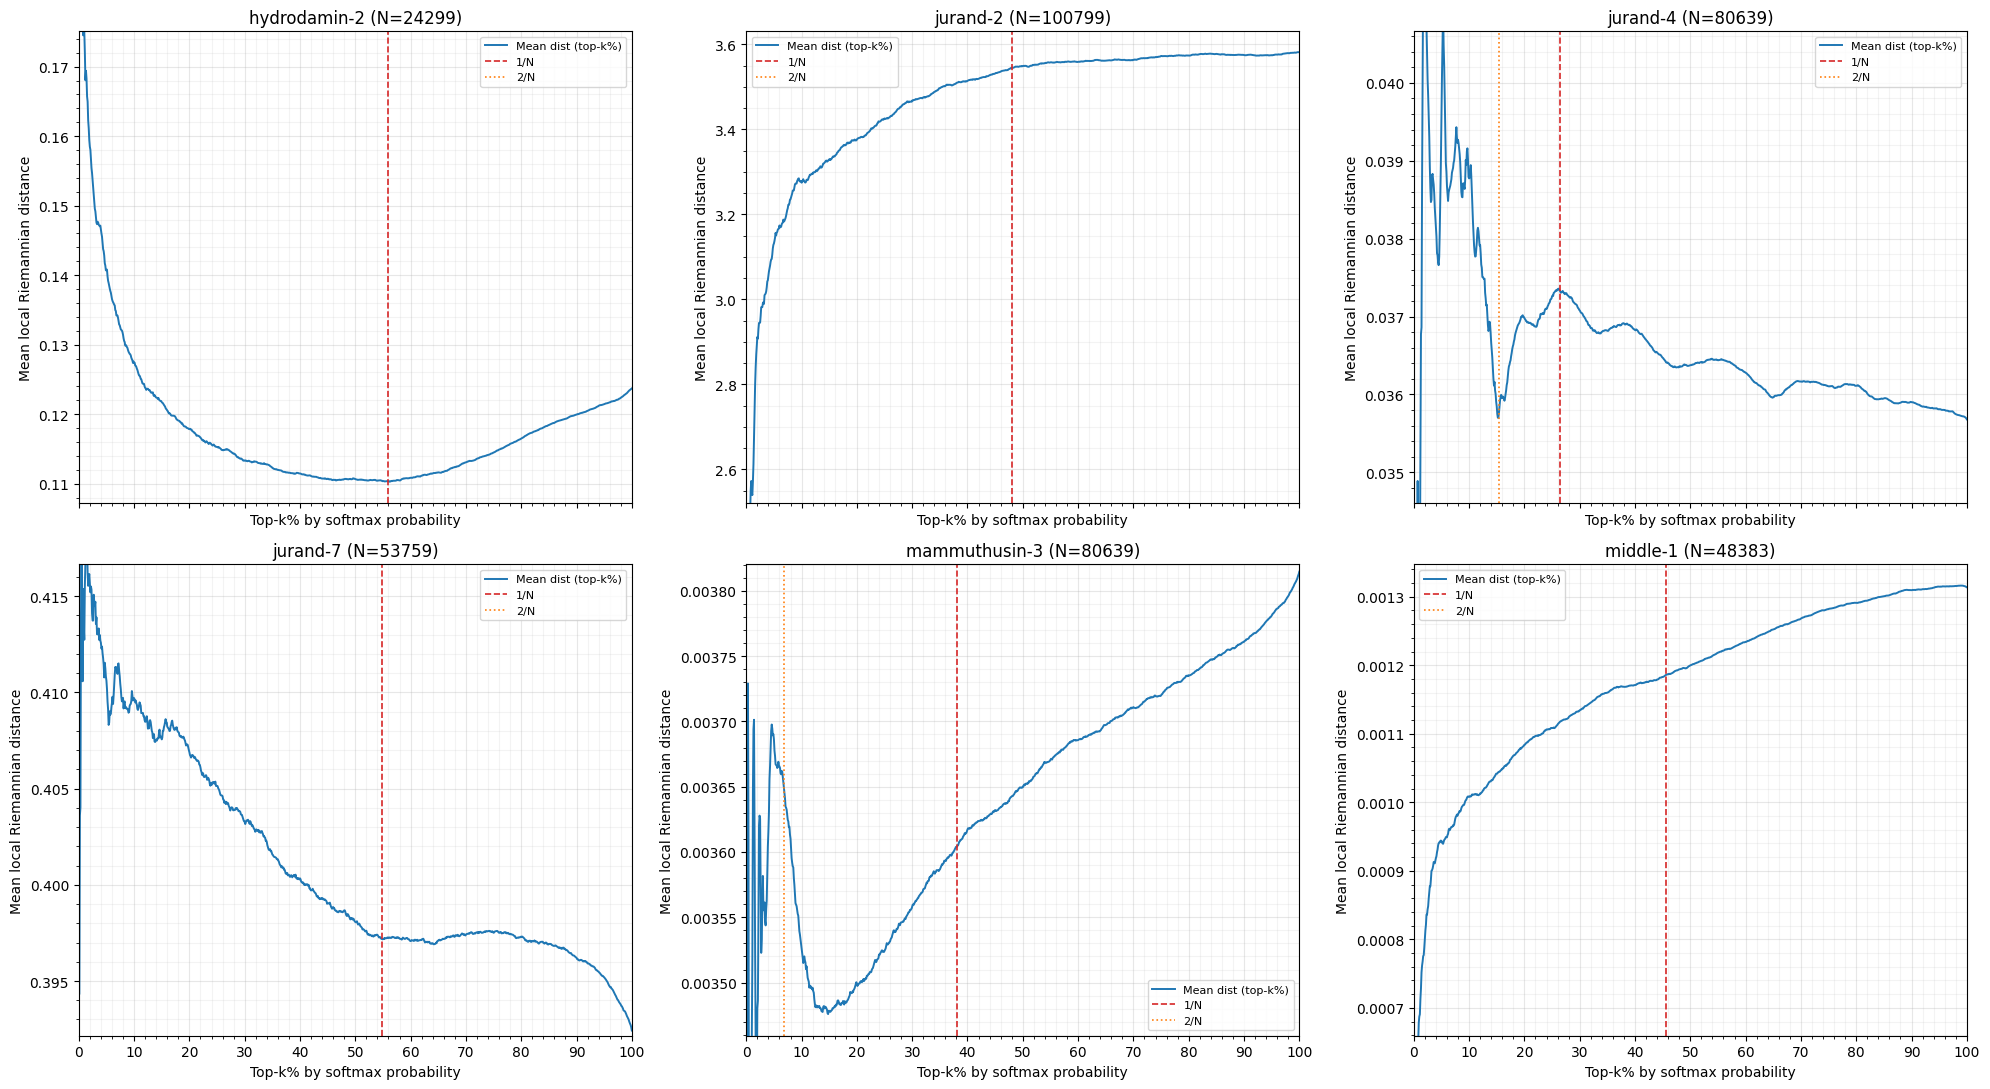

,run_name,start_peptide,num_candidates,mean_distance_all,mean_distance_above_1N,threshold_1_over_N,threshold_2_over_N,x_percent_for_1_over_N,x_percent_for_2_over_N,direction_significance_threshold,token_threshold,total_combos
0,hydrodamin-2,RMARNLVRYVQGLKKKKVI,24299,0.123706,0.110346,0.000041,0.000082,55.874727,0.000000,0.000500,0.0010,40500
1,jurand-2,KFRNRHRWKFKLIFRN,100799,3.581884,3.545508,0.000010,0.000020,47.989563,0.000000,0.000060,0.0001,138240
2,jurand-4,KYCRRFRWLTFRWL,80639,0.035680,0.037318,0.000012,0.000025,26.515706,15.342452,0.000002,0.0001,100800
3,jurand-7,KKYWLIRKWIRLWFLT,53759,0.392428,0.397190,0.000019,0.000037,54.859651,0.000000,0.000100,0.0005,120960
4,mammuthusin-3,KTLKIIRLLF,80639,0.003815,0.003604,0.000012,0.000025,38.032466,6.737435,0.000001,0.0001,80640
5,middle-1,FLYKWWIRIGRLKL,48383,0.001314,0.001185,0.000021,0.000041,45.530455,0.000000,0.000001,0.0001,48384


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11), sharex=True, sharey=False)
axes = axes.ravel()

for i, run_name in enumerate(summary_df["run_name"]):
    ax = axes[i]
    tmp = curve_df[curve_df["run_name"] == run_name].sort_values("k_percent")
    row = summary_df[summary_df["run_name"] == run_name].iloc[0]

    y_vals = tmp["mean_distance_top_k"].to_numpy(dtype=float)

    ax.plot(
        tmp["k_percent"],
        y_vals,
        lw=1.4,
        color="tab:blue",
        label="Mean dist (top-k%)",
    )
    ax.axvline(row["x_percent_for_1_over_N"], color="tab:red", linestyle="--", lw=1.2, label="1/N")
    ax.axvline(row["x_percent_for_2_over_N"], color="tab:orange", linestyle=":", lw=1.2, label="2/N")

    # Light major/minor grids help readability for dense 0.1% curves.
    ax.minorticks_on()
    ax.grid(alpha=0.3, which="major")
    ax.grid(alpha=0.15, which="minor")

    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 10))
    ax.set_title(f"{run_name} (N={int(row['num_candidates'])})")
    ax.set_xlabel("Top-k% by softmax probability")

    # Per-subplot robust y-range: use central bulk with small padding.
    y_low = float(np.nanpercentile(y_vals, 1))
    y_high = float(np.nanpercentile(y_vals, 99))

    if not np.isfinite(y_low):
        y_low = float(np.nanmin(y_vals))
    if not np.isfinite(y_high):
        y_high = float(np.nanmax(y_vals))

    if y_high <= y_low:
        y_low = float(np.nanmin(y_vals))
        y_high = float(np.nanmax(y_vals))

    span = y_high - y_low
    if not np.isfinite(span) or span <= 0:
        center = y_low if np.isfinite(y_low) else 0.0
        y_low = max(0.0, center - 1e-6)
        y_high = center + 1e-6
    else:
        pad = 0.05 * span
        y_low = max(0.0, y_low - pad)
        y_high = y_high + pad

    ax.set_ylim(y_low, y_high)
    ax.set_ylabel("Mean local Riemannian distance")
    ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plot_out = (results_dir / "plots" / "all_6_geodesic_topk_0p1pct.png")
plot_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_out, dpi=220, bbox_inches="tight")
print(f"Saved plot: {plot_out}")
plt.show()

summary_df